In [ ]:
# !pip install -U torch torchvision

In [ ]:
# !pip uninstall -y torchaudio torchvision

In [ ]:
# import os

# os.environ["DISABLE_TORCHVISION"] = "1"

In [ ]:
import torch

# print(torch.__version__)

try:
    import torchvision
    print(torchvision.__version__)
except Exception as e:
    print(e)

0.26.0+cu128


In [ ]:
import sys

print("torchvision loaded:", "torchvision" in sys.modules)

if "torchvision" in sys.modules:
    print(sys.modules["torchvision"])

torchvision loaded: True
<module 'torchvision' from '/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py'>


In [ ]:
# import torch
# import torchvision
# import transformers
# import datasets

# print("Torch       :", torch.__version__)
# print("Torchvision :", torchvision.__version__)
# print("Transformers:", transformers.__version__)
# print("Datasets    :", datasets.__version__)

In [1]:
import pandas as pd

In [3]:
df_annotate = pd.read_csv("data_annotate_explode.csv")
df_annotate

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,text_id,annotator_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text,processed_text,is_valid
0,0,0,0,2026-01-01 00:00:00,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...,True
1,1,0,0,2026-01-01 00:00:00,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...,True
2,2,1,0,2026-01-01 00:00:00,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,"Birruh, Biddam, Nafdiika ya Aqsaa ✊🇵🇸 Cukup ja...","birruh, biddam, nafdiika ya aqsaa cukup jadi m...",True
3,3,1,0,2026-01-01 00:00:00,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,"Birruh, Biddam, Nafdiika ya Aqsaa ✊🇵🇸 Cukup ja...","birruh, biddam, nafdiika ya aqsaa cukup jadi m...",True
4,4,2,1,2026-01-10 00:00:00,7,Elektabilitas Paslon 02 sebentar lagi terjun b...,Disabilitas,0,0,1,0,0,0,0,0,Elektabilitas pasangan calon 02 sebentar lagi ...,elektabilitas pasangan calon sebentar lagi ter...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51998,51998,26382,27827,4-994,19,@pippsstudy abis packing nnt ingfokan cowo kri...,Kristen,0,0,0,0,0,0,0,0,"@pippsstudy Abis packing, nanti infokan cowok ...","abis packing, nanti infokan cowok kristen.",True
51999,51999,26383,27828,4-995,19,Akun WhatsApp Pj Bupati Tegal Agustyarsah,UNKNOWN,0,0,0,0,0,0,0,0,Akun WhatsApp Pj Bupati Tegal Agustyarsah,akun whatsapp pj bupati tegal agustyarsah,True
52000,52000,26384,27829,4-996,19,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,"Jewish, Rohingya",0,0,1,0,0,0,0,0,Bulldozer Israel menabrak pengungsi pasien Rum...,bulldozer israel menabrak pengungsi pasien rum...,True
52001,52001,26385,27831,4-998,19,Perayaan Chinese New Year tahun ini ya akan ma...,Tionghoa,0,0,0,0,0,0,0,0,Perayaan Chinese New Year tahun ini akan makin...,perayaan chinese new year tahun ini akan makin...,True


In [ ]:
# df_annotate.drop(columns =['Unnamed: 0', 'agreement_is_noise_or_spam_text', 'agreement_related_to_election_2024',
#         'agreement_toxicity','agreement_polarized', 'agreement_profanity_obscenity', 'agreement_threat_incitement_to_violence',
#         'agreement_insults','agreement_identity_attack', 'agreement_sexually_explicit'], inplace = True)

In [4]:
df_annotate.columns.to_list()

['Unnamed: 0.2',
 'Unnamed: 0.1',
 'Unnamed: 0',
 'text_id',
 'annotator_id',
 'text',
 'topic',
 'is_noise_or_spam_text',
 'toxicity',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit',
 'cleaned_text',
 'processed_text',
 'is_valid']

In [5]:
df_annotate.drop(columns =['Unnamed: 0.1', 'Unnamed: 0', 'Unnamed: 0.2', 'is_valid'], inplace = True)
df_annotate.columns.to_list()

['text_id',
 'annotator_id',
 'text',
 'topic',
 'is_noise_or_spam_text',
 'toxicity',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit',
 'cleaned_text',
 'processed_text']

In [6]:
df_annotator = pd.read_csv("annotator_demographic.csv")
df_annotator

,annotator_id,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,1,Tionghoa,Kristen,no,no,F,50,Jakarta,Diploma,Bekerja,2
1,2,Madura,Islam,no,no,F,22,Madura,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,3,Batak,Kepercayaan Lokal,no,no,F,29,Medan,Sarjana (S1),Bekerja,3
3,4,Bali,Hindu,no,no,M,23,Bandung,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,-
4,5,Jawa,Syiah,no,no,M,46,Bandung,Diploma,Bekerja,Golput
5,6,Minang,Ahmadiyah,no,no,F,22,Jakarta,Sarjana (S1),Bekerja,3
6,7,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
7,8,Arab,Islam,no,no,M,23,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,1
8,9,Jawa,Islam,no,no,F,21,Magelang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,2
9,10,Tionghoa,Buddha,no,no,F,20,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3


In [7]:
annotate_columns = df_annotate.drop(['annotator_id', 'text_id'], axis=1).columns.to_list()
annotator_columns = df_annotator.drop(['annotator_id'], axis=1).columns.to_list()

print(annotate_columns)
print(annotator_columns)

['text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text']
['ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning']


In [ ]:
# import ast
# import pandas as pd

# def check_literal(x):
#     try:
#         ast.literal_eval(x)
#         return True
#     except:
#         return False

# df_annotate["is_valid"] = df_annotate["annotators_id"].apply(check_literal)

# # Tampilkan data yang error
# df_error = df_annotate[~df_annotate["is_valid"]]

# df_error[["annotators_id"]]

,annotators_id
6186,"['20', '5', 33']"
6188,"['20', '5', 33']"
11083,"['11', '18', 34']"
11179,"['21', '18', '34]"
11395,"['20', '18', '23', '31', '34]"
23644,"['19', '18', '34]"


In [ ]:
# import re
# def fix_annotators_id(value):
#     if pd.isna(value):
#         return value

#     value = str(value).strip()

#     # Coba parse terlebih dahulu
#     try:
#         result = ast.literal_eval(value)
#         return str(result)
#     except:
#         pass

#     # Pastikan dia memang berbentuk [...]
#     if value.startswith("["):

#         # Ambil semua angka di dalam string
#         numbers = re.findall(r"\d+", value)

#         # Kalau ada angka, bentuk ulang menjadi list string
#         if numbers:
#             return str(numbers)

#     return value

In [ ]:
# df_annotate["annotators_id"] = (
#     df_annotate["annotators_id"]
#     .apply(fix_annotators_id)
# )

In [ ]:
df_annotate = df_annotate.dropna()

In [ ]:
import ast

df_annotate["annotators_id"] = df_annotate["annotators_id"].apply(
    ast.literal_eval
)

df_annotate

,text_id,annotators_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text,processed_text,is_valid
0,2026-01-01 00:00:00,"[7, 15]",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']",Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...,True
1,2026-01-01 00:00:00,"[7, 15]",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","Birruh, Biddam, Nafdiika ya Aqsaa ✊🇵🇸 Cukup ja...","birruh, biddam, nafdiika ya aqsaa cukup jadi m...",True
2,2026-01-10 00:00:00,"[7, 15]",Elektabilitas Paslon 02 sebentar lagi terjun b...,Disabilitas,0,"['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']",Elektabilitas pasangan calon 02 sebentar lagi ...,elektabilitas pasangan calon sebentar lagi ter...,True
3,1-1001,"[10, 18]","Kristen, Hindu, Islam dapat perlakuan istimewa...",Kristen,0,"['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","Kristen, Hindu, Islam dapat perlakuan istimewa...","kristen, hindu, islam dapat perlakuan istimewa...",True
4,1-1004,"[10, 18]","Masyarakat Kristen, Hindu, Budha, dan etnis Ti...","Kristen, Tionghoa",0,"['0', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","Masyarakat Kristen, Hindu, Buddha, dan etnis T...","masyarakat kristen, hindu, buddha, dan etnis t...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26382,4-994,[19],@pippsstudy abis packing nnt ingfokan cowo kri...,Kristen,0,['0'],['0'],['0'],['0'],['0'],['0'],['0'],"@pippsstudy Abis packing, nanti infokan cowok ...","abis packing, nanti infokan cowok kristen.",True
26383,4-995,[19],Akun WhatsApp Pj Bupati Tegal Agustyarsah,UNKNOWN,0,['0'],['0'],['0'],['0'],['0'],['0'],['0'],Akun WhatsApp Pj Bupati Tegal Agustyarsah,akun whatsapp pj bupati tegal agustyarsah,True
26384,4-996,[19],Buldoser Israel Menabrak Pengungsi Pasien Ruma...,"Jewish, Rohingya",0,['0'],['1'],['0'],['0'],['0'],['0'],['0'],Bulldozer Israel menabrak pengungsi pasien Rum...,bulldozer israel menabrak pengungsi pasien rum...,True
26385,4-998,[19],Perayaan Chinese New Year tahun ini ya akan ma...,Tionghoa,0,['0'],['0'],['0'],['0'],['0'],['0'],['0'],Perayaan Chinese New Year tahun ini akan makin...,perayaan chinese new year tahun ini akan makin...,True


In [ ]:
# df_annotate_exp = df_annotate.explode(
#     [
#         "annotators_id",
#         "toxicity",
#         "polarized",
#         "profanity_obscenity",
#         "threat_incitement_to_violence",
#         "insults",
#         "identity_attack",
#         "sexually_explicit"
#     ]
# )

# df_annotate_exp = df_annotate_exp.rename(
#     columns={"annotators_id": "annotator_id"}
# )

# df_annotate_exp

ValueError: columns must have matching element counts

In [ ]:
# df_annotate_exp = df_annotate.explode("annotators_id")
# df_annotate_exp = df_annotate_exp.rename(
#     columns={"annotators_id": "annotator_id"}
# )

# df_annotate_exp

,text_id,annotator_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text,processed_text,is_valid
0,2026-01-01 00:00:00,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']",Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...,True
0,2026-01-01 00:00:00,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']",Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...,True
1,2026-01-01 00:00:00,7,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","Birruh, Biddam, Nafdiika ya Aqsaa ✊🇵🇸 Cukup ja...","birruh, biddam, nafdiika ya aqsaa cukup jadi m...",True
1,2026-01-01 00:00:00,15,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","Birruh, Biddam, Nafdiika ya Aqsaa ✊🇵🇸 Cukup ja...","birruh, biddam, nafdiika ya aqsaa cukup jadi m...",True
2,2026-01-10 00:00:00,7,Elektabilitas Paslon 02 sebentar lagi terjun b...,Disabilitas,0,"['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']",Elektabilitas pasangan calon 02 sebentar lagi ...,elektabilitas pasangan calon sebentar lagi ter...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26382,4-994,19,@pippsstudy abis packing nnt ingfokan cowo kri...,Kristen,0,['0'],['0'],['0'],['0'],['0'],['0'],['0'],"@pippsstudy Abis packing, nanti infokan cowok ...","abis packing, nanti infokan cowok kristen.",True
26383,4-995,19,Akun WhatsApp Pj Bupati Tegal Agustyarsah,UNKNOWN,0,['0'],['0'],['0'],['0'],['0'],['0'],['0'],Akun WhatsApp Pj Bupati Tegal Agustyarsah,akun whatsapp pj bupati tegal agustyarsah,True
26384,4-996,19,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,"Jewish, Rohingya",0,['0'],['1'],['0'],['0'],['0'],['0'],['0'],Bulldozer Israel menabrak pengungsi pasien Rum...,bulldozer israel menabrak pengungsi pasien rum...,True
26385,4-998,19,Perayaan Chinese New Year tahun ini ya akan ma...,Tionghoa,0,['0'],['0'],['0'],['0'],['0'],['0'],['0'],Perayaan Chinese New Year tahun ini akan makin...,perayaan chinese new year tahun ini akan makin...,True


In [ ]:
df_annotate_exp = df_annotate
df_annotate_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52003 entries, 0 to 52002
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        52003 non-null  object
 1   annotator_id                   52003 non-null  int64 
 2   text                           52003 non-null  object
 3   topic                          52003 non-null  object
 4   is_noise_or_spam_text          52003 non-null  int64 
 5   toxicity                       52003 non-null  int64 
 6   polarized                      52003 non-null  int64 
 7   profanity_obscenity            52003 non-null  int64 
 8   threat_incitement_to_violence  52003 non-null  int64 
 9   insults                        52003 non-null  int64 
 10  identity_attack                52003 non-null  int64 
 11  sexually_explicit              52003 non-null  int64 
 12  cleaned_text                   52003 non-null  object
 13  p

In [ ]:
df_annotate_exp.to_csv("data_thesis_after_explode.csv")
df_annotate.to_csv("data_thesis2.csv")

In [ ]:
df_annotate_exp["annotator_id"] = df_annotate_exp["annotator_id"].astype(str)
df_annotator["annotator_id"] = df_annotator["annotator_id"].astype(str)

In [ ]:
df = df_annotate_exp.merge(
    df_annotator,
    on="annotator_id",
    how="left"
)
df = df.drop(['text_id', 'annotator_id'], axis=1)
df

,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,...,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
1,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,...,Tionghoa,Katolik,yes,no,F,21,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
3,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,...,Tionghoa,Katolik,yes,no,F,21,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
4,Elektabilitas Paslon 02 sebentar lagi terjun b...,Disabilitas,0,0,1,0,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51998,@pippsstudy abis packing nnt ingfokan cowo kri...,Kristen,0,0,0,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
51999,Akun WhatsApp Pj Bupati Tegal Agustyarsah,UNKNOWN,0,0,0,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
52000,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,"Jewish, Rohingya",0,0,1,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
52001,Perayaan Chinese New Year tahun ini ya akan ma...,Tionghoa,0,0,0,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2


In [ ]:
df.to_csv("data_thesis_merged_metadata.csv")

#Preprocessing

In [ ]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "lu": "kamu",
    "loe": "kamu",
    "gw": "saya",
    "gue": "saya",
    "bgt": "banget",
    "dgn": "dengan",
    "krn": "karena",
    "aja": "saja",
    "trs": "terus"
}

In [ ]:
import re

def normalize_slang(text, slang_dict):
    words = text.split()
    return " ".join([slang_dict.get(w.lower(), w) for w in words])

def preprocess_text(text, slang_dict, lowercase=True):
    if not isinstance(text, str):
        return ""

    # 1. remove username (@user)
    text = re.sub(r'@\w+', '', text)

    # 2. remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. remove unwanted symbols (keep .,!?)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # 5. normalize slang
    text = normalize_slang(text, slang_dict)

    # 6. normalize repeated chars (contoh: anjiiing → anjiing)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. lowercase (optional)
    if lowercase:
        text = text.lower()

    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
from tqdm import tqdm
tqdm.pandas()

df["processed_text"] = (
    df["cleaned_text"]
    .fillna("")
    .astype(str)
    .progress_apply(
        lambda x: preprocess_text(x, slang_dict)
    )
)

100%|██████████| 52003/52003 [00:02<00:00, 18951.37it/s]


In [ ]:
df.to_csv("dataset_final.csv")

In [17]:
import pandas as pd
df = pd.read_csv(
    "dataset_final.csv",
    encoding="utf-8-sig",
    engine="python"
)
df

,Unnamed: 0,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,...,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,0,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
1,1,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,...,Tionghoa,Katolik,yes,no,F,21,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,2,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
3,3,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,...,Tionghoa,Katolik,yes,no,F,21,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
4,4,Elektabilitas Paslon 02 sebentar lagi terjun b...,Disabilitas,0,0,1,0,0,0,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51998,51998,@pippsstudy abis packing nnt ingfokan cowo kri...,Kristen,0,0,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
51999,51999,Akun WhatsApp Pj Bupati Tegal Agustyarsah,UNKNOWN,0,0,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
52000,52000,Buldoser Israel Menabrak Pengungsi Pasien Ruma...,"Jewish, Rohingya",0,0,1,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
52001,52001,Perayaan Chinese New Year tahun ini ya akan ma...,Tionghoa,0,0,0,0,0,0,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2


#Stage 1

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

In [ ]:
# !pip uninstall -y torch torchvision torchaudio

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModel,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
x = df.drop(columns=['toxicity'])
y = df['toxicity']

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

In [ ]:
print(dataset["train"].column_names)

['Unnamed: 0', 'text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', '__index_level_0__']


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in annotator_columns:

    le = LabelEncoder()

    df[col] = df[col].astype(str)

    df[col] = le.fit_transform(df[col])

    encoders[col] = le


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

def tokenize(batch):
    combined_texts = []

    for i in range(len(batch["processed_text"])):

        metadata_text = (
            f"Annotator memiliki etnis {batch['ethnicity'][i]}, "
            f"agama {batch['religion'][i]}, "
            f"status disabilitas {batch['disability'][i]}, "
            f"status LGBT {batch['lgbt'][i]}, "
            f"gender {batch['gender'][i]}, "
            f"usia {batch['age'][i]}, "
            f"berdomisili di {batch['domisili'][i]}, "
            f"pendidikan terakhir {batch['pendidikan terakhir'][i]}, "
            f"status pekerjaan {batch['status pekerjaan'][i]}, "
            f"dan kecenderungan pilihan presiden {batch['president vote leaning'][i]}."
        )

        combined_text = (
            f"{metadata_text} "
            f"Komentar yang dianotasi: {batch['processed_text'][i]}"
        )

        combined_texts.append(combined_text)

    tokenized = tokenizer(
        combined_texts,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    tokenized["combined_text"] = combined_texts

    # =========================
    # FIX LABEL
    # =========================
    labels = []

    for label in batch["toxicity"]:

        # Contoh: "['0']" -> ['0']
        if isinstance(label, str):
            label = ast.literal_eval(label)

        # Contoh: ['0'] -> '0'
        if isinstance(label, list):
            label = label[0]

        # Contoh: '0' -> 0
        labels.append(int(label))

    tokenized["labels"] = labels

    return tokenized

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
tokenized_datasets_1 = dataset.map(
    tokenize,
    batched=True
)

print(tokenized_datasets_1)

Map:   0%|          | 0/41602 [00:00<?, ? examples/s]

Map:   0%|          | 0/10401 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'combined_text', 'labels'],
        num_rows: 41602
    })
    test: Dataset({
        features: ['Unnamed: 0', 'text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', '__index_level_0__', 'input_ids', 'token_typ

In [ ]:
tokenized_datasets_1 = tokenized_datasets_1.remove_columns([
    "processed_text",
    "cleaned_text",
    "toxicity",
    "text",
    "__index_level_0__"
] + annotator_columns)

print(tokenized_datasets_1["train"].column_names)

tokenized_datasets_1.set_format("torch")

['Unnamed: 0', 'topic', 'is_noise_or_spam_text', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'input_ids', 'token_type_ids', 'attention_mask', 'combined_text', 'labels']


In [ ]:
from transformers import AutoModelForSequenceClassification

model_s1 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=2
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  445MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
def compute_metrics_s1(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [ ]:
from transformers import TrainingArguments, Trainer

args_s1 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=False,
    load_best_model_at_end=True
)

trainer_s1 = Trainer(
    model=model_s1,
    args=args_s1,
    train_dataset=tokenized_datasets_1['train'],
    eval_dataset=tokenized_datasets_1['test'],
    compute_metrics=compute_metrics_s1
)


model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
print(trainer_s1.train_dataset.column_names)

['Unnamed: 0', 'topic', 'is_noise_or_spam_text', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'input_ids', 'token_type_ids', 'attention_mask', 'combined_text', 'labels']


In [ ]:
import inspect

print(inspect.signature(trainer_s1.model.forward))

(input_ids: torch.Tensor | None = None, attention_mask: torch.Tensor | None = None, token_type_ids: torch.Tensor | None = None, position_ids: torch.Tensor | None = None, inputs_embeds: torch.Tensor | None = None, labels: torch.Tensor | None = None, **kwargs: Unpack[transformers.utils.generic.TransformersKwargs]) -> tuple[torch.Tensor] | transformers.modeling_outputs.SequenceClassifierOutput


In [ ]:
# !pip show torch torchvision

In [ ]:
import sys
import datasets

# Matikan torchvision di runtime
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

# Paksa datasets menganggap torchvision tidak tersedia
datasets.config.TORCHVISION_AVAILABLE = False

print("TORCHVISION_AVAILABLE:", datasets.config.TORCHVISION_AVAILABLE)
print("torchvision loaded:", "torchvision" in sys.modules)

TORCHVISION_AVAILABLE: False
torchvision loaded: False


In [ ]:
print("=== TRAINER ===")
print("label_names:", trainer_s1.label_names)
print("remove_unused_columns:", trainer_s1.args.remove_unused_columns)

print("\n=== DATASET ===")
print(trainer_s1.train_dataset.column_names)

print("\n=== SAMPLE ===")
sample = trainer_s1.train_dataset[0]
print(sample.keys())
print("labels:", sample.get("labels"))

print("\n=== MODEL ===")
print(type(trainer_s1.model))

=== TRAINER ===
label_names: ['labels']
remove_unused_columns: False

=== DATASET ===
['Unnamed: 0', 'topic', 'is_noise_or_spam_text', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'input_ids', 'token_type_ids', 'attention_mask', 'combined_text', 'labels']

=== SAMPLE ===
dict_keys(['Unnamed: 0', 'topic', 'is_noise_or_spam_text', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'input_ids', 'token_type_ids', 'attention_mask', 'combined_text', 'labels'])
labels: tensor(1)

=== MODEL ===
<class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>


In [ ]:
trainer_s1.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.027169,0.321868,0.870109,0.627926
2,0.053608,0.323628,0.879915,0.646676
3,0.000939,0.382602,0.883088,0.636364
4,0.018474,0.395117,0.882127,0.657924
5,0.013947,0.426672,0.882896,0.660913


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=26005, training_loss=0.28876588480568377, metrics={'train_runtime': 5622.3409, 'train_samples_per_second': 36.997, 'train_steps_per_second': 4.625, 'total_flos': 1.36824326563584e+16, 'train_loss': 0.28876588480568377, 'epoch': 5.0})

In [ ]:
history = trainer_s1.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = [x['epoch'] for x in history if 'eval_loss' in x]

In [ ]:
from matplotlib import pyplot as plt

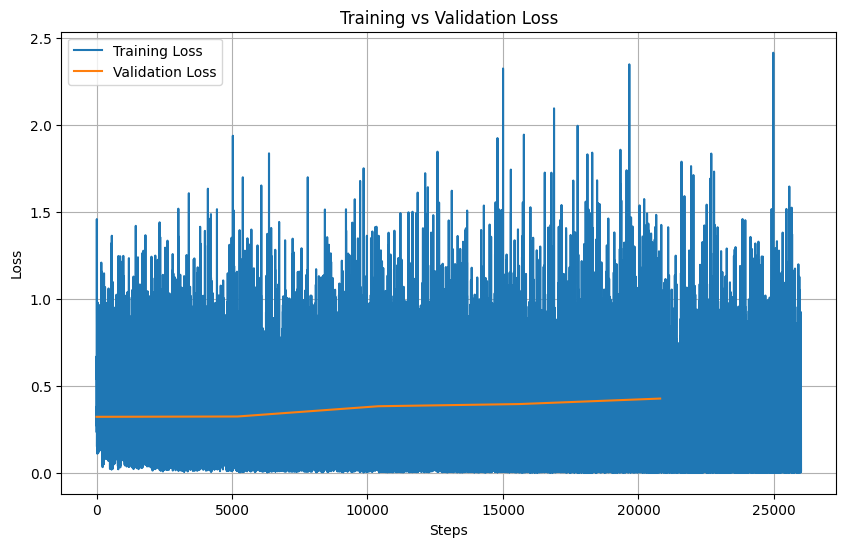

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#Stage 2

In [18]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

In [19]:
df_2 = df[df['toxicity'] == 1]
y = df_2[LABEL_COLS]
df_2

,Unnamed: 0,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,...,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
18,18,"Apakah kita harus di pimpin oleh orang yg,waki...",Disabilitas,0,1,0,0,0,1,0,...,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
29,29,Video Wanita Muslim Memaksa Wanita Hindu untuk...,UNKNOWN,0,1,1,0,0,0,1,...,Bali,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2
30,30,Video “Tentara Cina Komunis Tiongkok Masuk Ind...,Tionghoa,0,1,1,0,0,1,0,...,Tionghoa,Buddha,no,no,F,20,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
31,31,Video “Tentara Cina Komunis Tiongkok Masuk Ind...,Tionghoa,0,1,1,0,0,0,1,...,Bali,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2
35,35,“di Morowali sejumlah TKA China menghakimi Pen...,Tionghoa,0,1,1,0,0,0,1,...,Bali,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51938,51938,@Heraloebss Usir Rohingya dari Aceh dan dari s...,Rohingya,0,1,1,0,1,0,1,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
51943,51943,Bismillah... Semoga orang yang mati-matian mem...,Syiah,0,1,1,0,0,0,1,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
51961,51961,"Gila ya , kalau umat bersatu habis juga itu ge...","LGBTQ+, Jewish, Disabilitas",0,1,1,0,1,1,0,...,Batak,Kristen,no,no,F,39,Depok,Magister (S2),Bekerja,2
51962,51962,"Gila ya , kalau umat bersatu habis juga itu ge...","LGBTQ+, Jewish, Disabilitas",0,1,1,0,0,1,1,...,Bali,Hindu,yes,no,M,34,Jakarta,Magister (S2),Tidak Bekerja,2


In [20]:
from sklearn.model_selection import train_test_split

train_df_s2, test_df_s2 = train_test_split(
    df_2,
    test_size=0.2,
    random_state=42
)

In [21]:
from datasets import Dataset, DatasetDict

dataset_s2 = DatasetDict({

    "train": Dataset.from_pandas(
        train_df_s2.reset_index(drop=True)
    ),

    "test": Dataset.from_pandas(
        test_df_s2.reset_index(drop=True)
    )
})

In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

def tokenize_multilabel(batch):

    combined_texts = []

    for i in range(len(batch["processed_text"])):

        metadata_text = (
            f"Annotator memiliki etnis {batch['ethnicity'][i]}, "
            f"agama {batch['religion'][i]}, "
            f"status disabilitas {batch['disability'][i]}, "
            f"status LGBT {batch['lgbt'][i]}, "
            f"gender {batch['gender'][i]}, "
            f"usia {batch['age'][i]}, "
            f"berdomisili di {batch['domisili'][i]}, "
            f"pendidikan terakhir {batch['pendidikan terakhir'][i]}, "
            f"status pekerjaan {batch['status pekerjaan'][i]}, "
            f"dan kecenderungan pilihan presiden {batch['president vote leaning'][i]}."
        )

        combined_text = (
            f"{metadata_text} "
            f"Komentar yang dianotasi: {batch['processed_text'][i]}"
        )

        combined_texts.append(combined_text)

    tokenized = tokenizer(
        combined_texts,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    # multilabel targets
    tokenized["labels"] = [
        [float(batch[col][i]) for col in LABEL_COLS]
        for i in range(len(batch["processed_text"]))
    ]

    tokenized["combined_text"] = combined_texts

    return tokenized

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [23]:
tokenized_datasets_2 = dataset_s2.map(
    tokenize_multilabel,
    batched=True
)

Map:   0%|          | 0/7444 [00:00<?, ? examples/s]

Map:   0%|          | 0/1861 [00:00<?, ? examples/s]

In [25]:
columns_to_remove = [
    "Unnamed: 0",
    "text",
    "initial_paragraph",
    "topic",
    "is_noise_or_spam_text",
    "toxicity",
    "polarized",
    "profanity_obscenity",
    "threat_incitement_to_violence",
    "insults",
    "identity_attack",
    "sexually_explicit",
    "cleaned_text",
    "processed_text",
    "ethnicity",
    "religion",
    "disability",
    "lgbt",
    "gender",
    "age",
    "domisili",
    "pendidikan terakhir",
    "status pekerjaan",
    "president vote leaning",
    "related_to_election_2024",
    "combined_text"
]

In [27]:
# Hanya hapus kolom yang benar-benar ada
columns_to_remove = [
    col for col in columns_to_remove
    if col in tokenized_datasets_2.column_names
]

tokenized_datasets_2 = tokenized_datasets_2.remove_columns(
    columns_to_remove
)

print(tokenized_datasets_2.column_names)

{'train': ['Unnamed: 0', 'text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'combined_text'], 'test': ['Unnamed: 0', 'text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'combined_text']}


In [24]:
# tokenized_datasets_2 = tokenized_datasets_2.remove_columns([
#     "text",
#     "initial_paragraph",
#     "topic",
#     "is_noise_or_spam_text",
#     "related_to_election_2024",
#     "toxicity",
#     "polarized",
#     "cleaned_text",
#     "processed_text"
# ] + annotator_columns + LABEL_COLS)

ValueError: Column name ['related_to_election_2024', 'initial_paragraph'] not in the dataset. Current columns in the dataset: ['Unnamed: 0', 'text', 'topic', 'is_noise_or_spam_text', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'processed_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'combined_text']

In [28]:
from transformers import AutoModelForSequenceClassification

model_2 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  445MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
import numpy as np
from sklearn.metrics import (
    f1_score,
    accuracy_score
)

def compute_metrics_multilabel(eval_pred):

    logits, labels = eval_pred

    predictions = (logits > 0).astype(int)

    f1_micro = f1_score(
        labels,
        predictions,
        average="micro"
    )

    f1_macro = f1_score(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro
    }

In [30]:
from transformers import TrainingArguments, Trainer

args_s2 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s2 = Trainer(
    model=model_2,
    args=args_s2,
    train_dataset=tokenized_datasets_2['train'],
    eval_dataset=tokenized_datasets_2['test'],
    compute_metrics=compute_metrics_multilabel
)


In [31]:
batch = tokenized_datasets_2["train"][:2]

print(batch["labels"])

[[1.0, 1.0, 0.0, 1.0, 0.0], [0.0, 1.0, 1.0, 0.0, 0.0]]


In [32]:
trainer_s2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro
1,0.299594,0.357465,0.481462,0.669480,0.570813
2,0.203044,0.341850,0.495433,0.685280,0.609540
3,0.608036,0.341164,0.502418,0.702622,0.633727
4,0.442918,0.338077,0.502418,0.697248,0.635025
5,0.196658,0.336214,0.508329,0.702211,0.643463


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4655, training_loss=0.3229355804406098, metrics={'train_runtime': 1302.5413, 'train_samples_per_second': 28.575, 'train_steps_per_second': 3.574, 'total_flos': 2448314315627520.0, 'train_loss': 0.3229355804406098, 'epoch': 5.0})

In [33]:
import numpy as np

predictions = trainer_s2.predict(
    tokenized_datasets_2["test"]
)

logits = predictions.predictions
labels = predictions.label_ids

probs = 1 / (1 + np.exp(-logits))

preds = (probs >= 0.5).astype(int)

In [34]:
from sklearn.metrics import classification_report

for i, label_name in enumerate(LABEL_COLS):

    print(f"\n===== {label_name} =====")

    print(
        classification_report(
            labels[:, i],
            preds[:, i]
        )
    )


===== insults =====
              precision    recall  f1-score   support

         0.0       0.74      0.76      0.75       996
         1.0       0.71      0.70      0.70       865

    accuracy                           0.73      1861
   macro avg       0.73      0.73      0.73      1861
weighted avg       0.73      0.73      0.73      1861


===== identity_attack =====
              precision    recall  f1-score   support

         0.0       0.86      0.79      0.82      1060
         1.0       0.75      0.83      0.79       801

    accuracy                           0.81      1861
   macro avg       0.81      0.81      0.81      1861
weighted avg       0.81      0.81      0.81      1861


===== threat_incitement_to_violence =====
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94      1634
         1.0       0.59      0.56      0.57       227

    accuracy                           0.90      1861
   macro avg       0.77      0.75  

In [35]:
import numpy as np
import torch

LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_2.to(device)

def predict_multilabel(
    text,
    ethnicity,
    religion,
    disability,
    lgbt,
    gender,
    age,
    domisili,
    pendidikan,
    pekerjaan,
    president_vote
):

    metadata_text = (
        f"Annotator memiliki etnis {ethnicity}, "
        f"agama {religion}, "
        f"status disabilitas {disability}, "
        f"status LGBT {lgbt}, "
        f"gender {gender}, "
        f"usia {age}, "
        f"berdomisili di {domisili}, "
        f"pendidikan terakhir {pendidikan}, "
        f"status pekerjaan {pekerjaan}, "
        f"dan kecenderungan pilihan presiden {president_vote}."
    )

    combined_text = (
        f"{metadata_text} "
        f"Komentar yang dianotasi: {text}"
    )

    inputs = tokenizer(
        combined_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # PINDAHKAN INPUT KE DEVICE
    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model_2(**inputs)

        probs = torch.sigmoid(
            outputs.logits
        ).cpu().numpy()[0]

    predictions = (probs >= 0.5).astype(int)

    result = {}

    for label, pred, prob in zip(
        LABEL_COLS,
        predictions,
        probs
    ):
        result[label] = {
            "prediction": int(pred),
            "probability": float(prob)
        }

    return {
        "combined_text": combined_text,
        "results": result
    }

In [36]:
predict_multilabel(
    text="dasar goblok banget lu",
    ethnicity="jawa",
    religion="islam",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="24",
    domisili="bandung",
    pendidikan="Sarjana",
    pekerjaan="mahasiswa",
    president_vote="2"
)

{'combined_text': 'Annotator memiliki etnis jawa, agama islam, status disabilitas tidak, status LGBT tidak, gender perempuan, usia 24, berdomisili di bandung, pendidikan terakhir Sarjana, status pekerjaan mahasiswa, dan kecenderungan pilihan presiden 2. Komentar yang dianotasi: dasar goblok banget lu',
 'results': {'insults': {'prediction': 1, 'probability': 0.7347505688667297},
  'identity_attack': {'prediction': 0, 'probability': 0.011708427220582962},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.04192351922392845},
  'profanity_obscenity': {'prediction': 1, 'probability': 0.6486185193061829},
  'sexually_explicit': {'prediction': 0, 'probability': 0.007656493224203587}}}

In [37]:
predict_multilabel(
    text="agama itu memang bikin orang jadi bodoh",
    ethnicity="batak",
    religion="kristen",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="30",
    domisili="medan",
    pendidikan="Sarjana",
    pekerjaan="pegawai swasta",
    president_vote="3"
)

{'combined_text': 'Annotator memiliki etnis batak, agama kristen, status disabilitas tidak, status LGBT tidak, gender perempuan, usia 30, berdomisili di medan, pendidikan terakhir Sarjana, status pekerjaan pegawai swasta, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: agama itu memang bikin orang jadi bodoh',
 'results': {'insults': {'prediction': 1, 'probability': 0.9428053498268127},
  'identity_attack': {'prediction': 0, 'probability': 0.039031825959682465},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.01038946583867073},
  'profanity_obscenity': {'prediction': 0, 'probability': 0.13631045818328857},
  'sexually_explicit': {'prediction': 0, 'probability': 0.006731904577463865}}}

In [39]:
predict_multilabel(
    text="ini israel kontol banget",
    ethnicity="batak",
    religion="kristen",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="30",
    domisili="medan",
    pendidikan="Sarjana",
    pekerjaan="pegawai swasta",
    president_vote="3"
)

{'combined_text': 'Annotator memiliki etnis batak, agama kristen, status disabilitas tidak, status LGBT tidak, gender perempuan, usia 30, berdomisili di medan, pendidikan terakhir Sarjana, status pekerjaan pegawai swasta, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: ini israel kontol banget',
 'results': {'insults': {'prediction': 1, 'probability': 0.6966677904129028},
  'identity_attack': {'prediction': 0, 'probability': 0.0997944325208664},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.015773482620716095},
  'profanity_obscenity': {'prediction': 1, 'probability': 0.7577757835388184},
  'sexually_explicit': {'prediction': 0, 'probability': 0.012834534980356693}}}

In [40]:
predict_multilabel(
    text="gila ini cewe seksi banget",
    ethnicity="batak",
    religion="kristen",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="30",
    domisili="medan",
    pendidikan="Sarjana",
    pekerjaan="pegawai swasta",
    president_vote="3"
)

{'combined_text': 'Annotator memiliki etnis batak, agama kristen, status disabilitas tidak, status LGBT tidak, gender perempuan, usia 30, berdomisili di medan, pendidikan terakhir Sarjana, status pekerjaan pegawai swasta, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: gila ini cewe seksi banget',
 'results': {'insults': {'prediction': 0, 'probability': 0.4483215808868408},
  'identity_attack': {'prediction': 0, 'probability': 0.030675694346427917},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.0052623744122684},
  'profanity_obscenity': {'prediction': 0, 'probability': 0.4465927183628082},
  'sexually_explicit': {'prediction': 0, 'probability': 0.044123098254203796}}}

In [43]:
predict_multilabel(
    text="cewe yg udah pernah tidur sama banyak cowo tuh emg masih bisa dibilang baik?",
    ethnicity="batak",
    religion="kristen",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="30",
    domisili="medan",
    pendidikan="Sarjana",
    pekerjaan="pegawai swasta",
    president_vote="3"
)

{'combined_text': 'Annotator memiliki etnis batak, agama kristen, status disabilitas tidak, status LGBT tidak, gender perempuan, usia 30, berdomisili di medan, pendidikan terakhir Sarjana, status pekerjaan pegawai swasta, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: cewe yg udah pernah tidur sama banyak cowo tuh emg masih bisa dibilang baik?',
 'results': {'insults': {'prediction': 1, 'probability': 0.9118967056274414},
  'identity_attack': {'prediction': 0, 'probability': 0.06704705208539963},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.008512924425303936},
  'profanity_obscenity': {'prediction': 0, 'probability': 0.0388331301510334},
  'sexually_explicit': {'prediction': 0, 'probability': 0.019408395513892174}}}

In [44]:
predict_multilabel(
    text="cewe yg udah pernah tidur sama banyak cowo tuh emg masih bisa dibilang baik?",
    ethnicity="jawa",
    religion="islam",
    disability="tidak",
    lgbt="tidak",
    gender="laki-laki",
    age="20",
    domisili="jakarta",
    pendidikan="SMA",
    pekerjaan="mahasiswa",
    president_vote="1"
)

{'combined_text': 'Annotator memiliki etnis jawa, agama islam, status disabilitas tidak, status LGBT tidak, gender laki-laki, usia 20, berdomisili di jakarta, pendidikan terakhir SMA, status pekerjaan mahasiswa, dan kecenderungan pilihan presiden 1. Komentar yang dianotasi: cewe yg udah pernah tidur sama banyak cowo tuh emg masih bisa dibilang baik?',
 'results': {'insults': {'prediction': 1, 'probability': 0.9391486048698425},
  'identity_attack': {'prediction': 0, 'probability': 0.05187002569437027},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.011335643008351326},
  'profanity_obscenity': {'prediction': 0,
   'probability': 0.037977445870637894},
  'sexually_explicit': {'prediction': 0, 'probability': 0.017772646620869637}}}

In [45]:
predict_multilabel(
    text="israel emg selalu salah ya? menurut gue masalahnya ga sesimpel itu",
    ethnicity="batak",
    religion="kristen",
    disability="tidak",
    lgbt="tidak",
    gender="perempuan",
    age="30",
    domisili="medan",
    pendidikan="Sarjana",
    pekerjaan="pegawai swasta",
    president_vote="3"
)

{'combined_text': 'Annotator memiliki etnis batak, agama kristen, status disabilitas tidak, status LGBT tidak, gender perempuan, usia 30, berdomisili di medan, pendidikan terakhir Sarjana, status pekerjaan pegawai swasta, dan kecenderungan pilihan presiden 3. Komentar yang dianotasi: israel emg selalu salah ya? menurut gue masalahnya ga sesimpel itu',
 'results': {'insults': {'prediction': 1, 'probability': 0.8211728930473328},
  'identity_attack': {'prediction': 0, 'probability': 0.15206792950630188},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.06284884363412857},
  'profanity_obscenity': {'prediction': 0,
   'probability': 0.011949331499636173},
  'sexually_explicit': {'prediction': 0,
   'probability': 0.0034138348419219255}}}

In [46]:
predict_multilabel(
    text="israel emg selalu salah ya? menurut gue masalahnya ga sesimpel itu",
    ethnicity="jawa",
    religion="islam",
    disability="tidak",
    lgbt="tidak",
    gender="laki-laki",
    age="20",
    domisili="jakarta",
    pendidikan="SMA",
    pekerjaan="mahasiswa",
    president_vote="1"
)

{'combined_text': 'Annotator memiliki etnis jawa, agama islam, status disabilitas tidak, status LGBT tidak, gender laki-laki, usia 20, berdomisili di jakarta, pendidikan terakhir SMA, status pekerjaan mahasiswa, dan kecenderungan pilihan presiden 1. Komentar yang dianotasi: israel emg selalu salah ya? menurut gue masalahnya ga sesimpel itu',
 'results': {'insults': {'prediction': 1, 'probability': 0.7246670722961426},
  'identity_attack': {'prediction': 0, 'probability': 0.06573332846164703},
  'threat_incitement_to_violence': {'prediction': 0,
   'probability': 0.22352206707000732},
  'profanity_obscenity': {'prediction': 0,
   'probability': 0.021918445825576782},
  'sexually_explicit': {'prediction': 0, 'probability': 0.003825061721727252}}}